# Step 2 – Return Computation and Exploratory Analysis

This notebook converts the raw daily price series into monthly log returns and performs initial exploratory data analysis.  
We inspect return distributions, pairwise correlations, and cumulative growth paths to gain an early understanding of the data characteristics before proceeding to signal construction.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import os

In [4]:
## 1. Import the Raw Price Data
We read the daily adjusted close CSV produced in the previous step and parse dates into a proper datetime index.


## 1. Convert Daily Prices to Monthly Frequency
We aggregate daily adjusted close prices to end-of-month values using `resample('ME').last()`.  
This reduces noise and aligns all assets on a common monthly timeline for backtesting.

In [5]:
## 2. Resample to Monthly Frequency
Daily prices are converted to end-of-month observations, since our momentum strategy operates at a monthly cadence. We keep only the last available price of each calendar month.


## 2. Compute Monthly Returns
Monthly returns are calculated as the percentage change of end-of-month prices. This time series will be used in the momentum ranking and portfolio construction stages.

In [6]:
## 3. Compute Monthly Log Returns
Logarithmic returns are calculated as $r_t = \ln(P_t / P_{t-1})$.  
Log returns are preferred because they are time-additive and more suitable for statistical analysis.


In [7]:
cumulative_growth_trajectories = (1 + log_returns_monthly).cumprod()

## 3. Visualize Price Evolution
The plot below shows the normalized price evolution of all stocks in the universe from 2000 to 2025.  
This helps visualize long-term trends and identify potential outliers (e.g., exceptionally strong performers like Apple or Amazon).

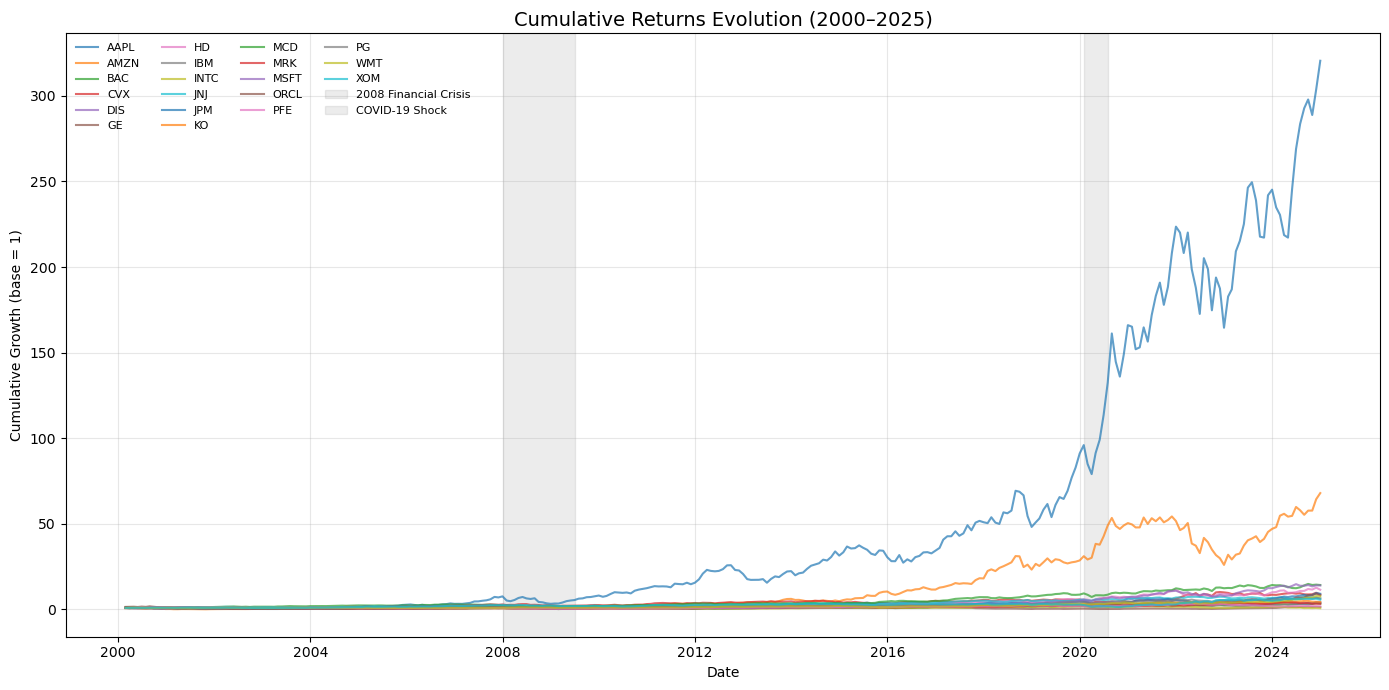

In [18]:
## 4. Distribution of Monthly Returns
The histograms below reveal the shape, skewness, and kurtosis of each equity’s return distribution. Heavier tails signal higher extreme-event risk.


In [9]:
tickers_no_outliers = [t for t in log_returns_monthly.columns if t not in ["AAPL", "AMZN"]]
monthly_returns_no_outliers = log_returns_monthly[tickers_no_outliers]
cumulative_returns_no_outliers = (1 + monthly_returns_no_outliers).cumprod()

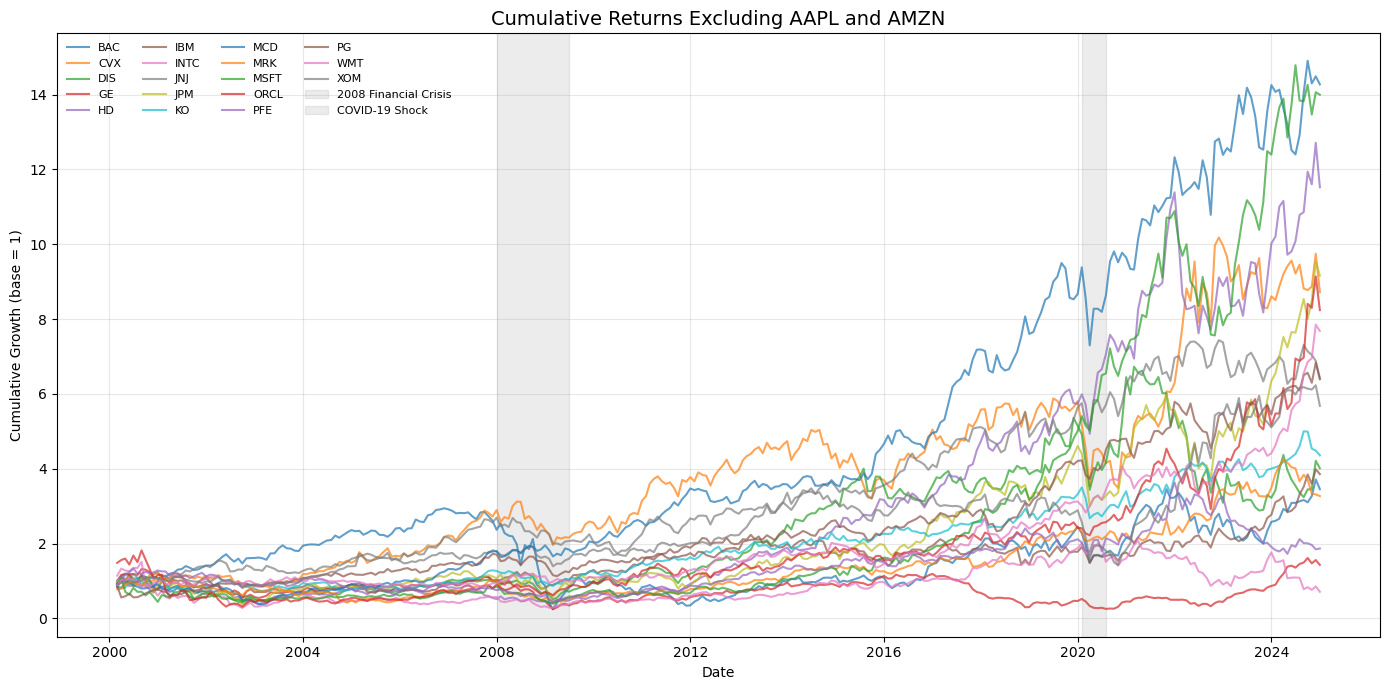

In [10]:
## 5. Pairwise Correlation Structure
The heatmap illustrates the linear co-movement between every pair of equities in the universe. Highly correlated assets tend to move together, which is important when constructing diversified portfolios.


## 4. Correlation Analysis
The heatmap below displays pairwise correlations between monthly returns.  
High correlations indicate similar sector or market exposure, while low correlations suggest diversification benefits.  
Two versions are produced:
- Including all tickers.  
- Excluding extreme performers (e.g., Apple, Amazon) to examine robustness.

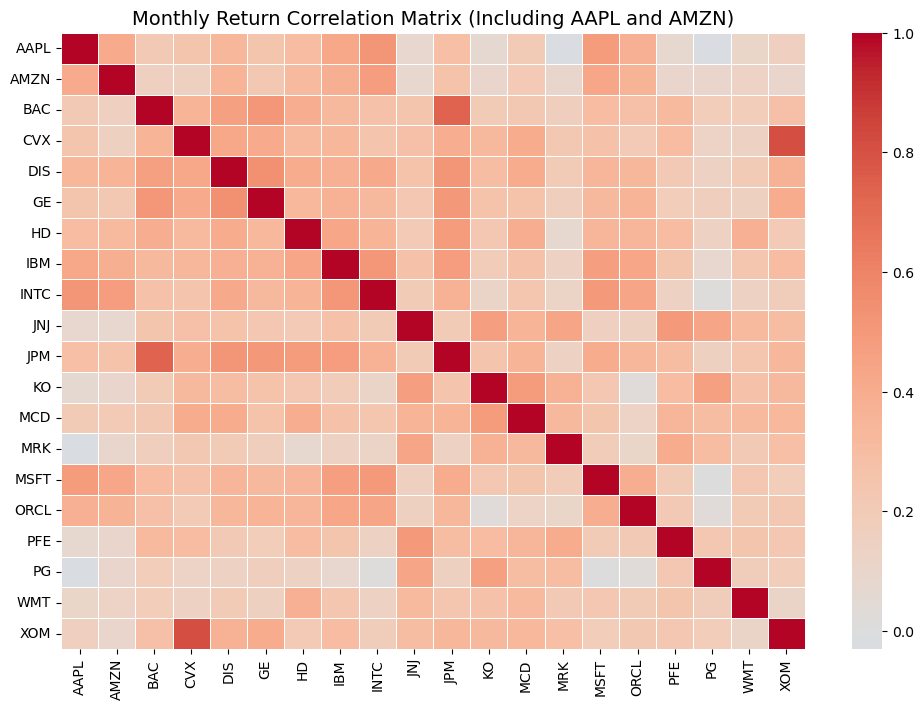

In [19]:
## 6. Cumulative Performance Overview
By plotting the cumulative product of $(1 + r_t)$ for each equity, we can visually compare long-term growth trajectories and identify standout performers.


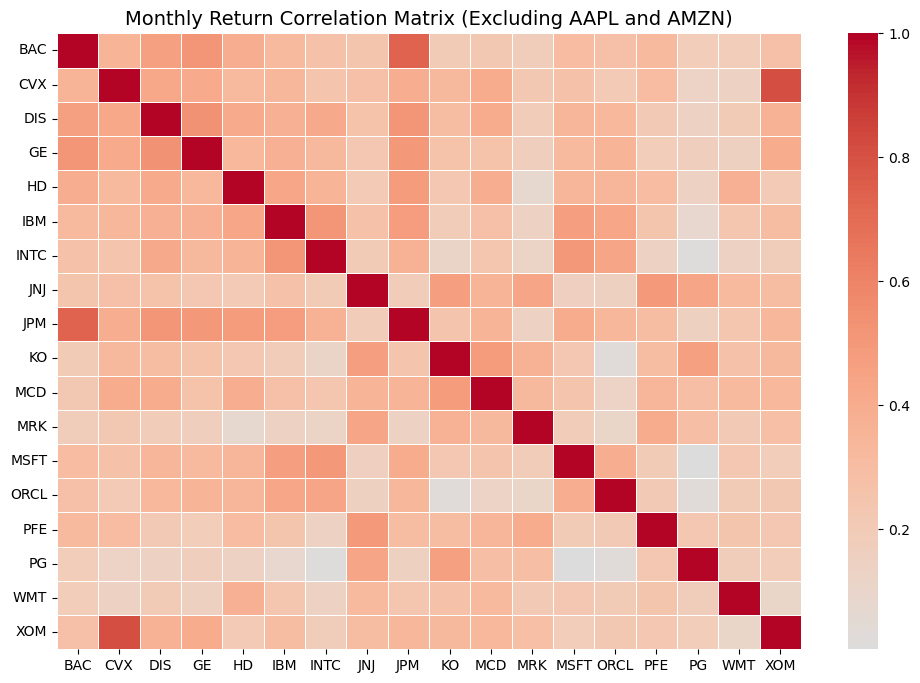

In [20]:
corr_no_outliers = monthly_returns_no_outliers.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_no_outliers, annot=False, cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Monthly Return Correlation Matrix (Excluding AAPL and AMZN)", fontsize=14)
plt.show()

## 7. Filtered View – Removing Extreme Outliers
For a cleaner visual comparison, we exclude stocks whose cumulative return far exceeds the rest of the panel, allowing the remaining growth curves to be displayed on a legible scale.


In [13]:
desc_stats = log_returns_monthly.describe().T
desc_stats["mean"] = log_returns_monthly.mean()
desc_stats["volatility"] = log_returns_monthly.std()
desc_stats["skewness"] = log_returns_monthly.skew()
desc_stats["kurtosis"] = log_returns_monthly.kurt()

desc_stats[["mean", "volatility", "skewness", "kurtosis"]].round(3)

,mean,volatility,skewness,kurtosis
AAPL,0.026,0.111,-0.588,3.581
AMZN,0.022,0.128,0.441,3.559
BAC,0.010,0.110,0.362,8.656
CVX,0.010,0.068,0.407,2.107
DIS,0.008,0.077,0.049,1.137
GE,0.005,0.088,0.217,2.255
HD,0.011,0.072,-0.161,0.267
IBM,0.007,0.072,0.365,3.208
INTC,0.004,0.099,-0.484,2.251
JNJ,0.007,0.047,-0.153,1.141


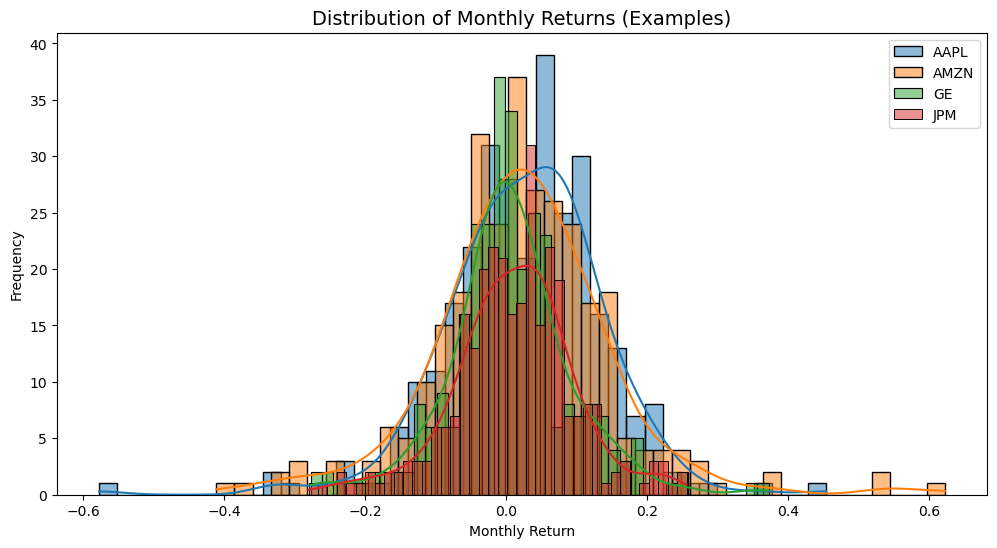

In [22]:
plt.figure(figsize=(12,6))
for ticker in ["AAPL", "AMZN", "GE", "JPM"]:  # 4 different examples
    sns.histplot(log_returns_monthly[ticker], kde=True, bins=40, label=ticker, alpha=0.5)

plt.title("Distribution of Monthly Returns (Examples)", fontsize=14)
plt.xlabel("Monthly Return")
plt.ylabel("Frequency")
plt.legend()
plt.show()

### Takeaways
- Monthly returns exhibit fat tails compared to a Gaussian distribution, reinforcing the need for robust risk metrics like Sortino.  
- The correlation matrix shows moderate positive correlation across most equities, with sector clusters clearly visible.  
- A small number of names (notably AAPL, AMZN) dominate long-run cumulative performance, which will naturally influence momentum rankings.

The processed monthly returns are saved and passed forward to the signal construction step.

In [23]:
benchmark_spy_data = yf.download("SPY", start="2000-01-01", end="2025-01-01", auto_adjust=True)["Close"]
spy_monthly = benchmark_spy_data.resample("ME").last().pct_change().dropna()

universe_mean_returns = log_returns_monthly.mean(axis=1)

spy_mean = spy_monthly.mean().item()
spy_vol = spy_monthly.std().item()

universe_mean = universe_mean_returns.mean()
universe_vol = universe_mean_returns.std()

# --- Comparative results matrix ---
comparison = pd.DataFrame({
    "Monthly mean": [spy_mean, universe_mean],
    "Monthly volatility": [spy_vol, universe_vol]
}, index=["SPY", "Universe (20 tickers)"])

print(comparison.round(4))

[*********************100%***********************]  1 of 1 completed

                       Monthly mean  Monthly volatility
SPY                          0.0073              0.0441
Universe (20 tickers)        0.0098              0.0438


### Summary
- Converted daily prices to monthly returns for all tickers (2000–2025).  
- Explored distributional properties and cross-correlations.  
- Compared universe statistics against SPY benchmark.  
- Dataset is now clean, validated, and ready for **momentum signal construction** in the next notebook.